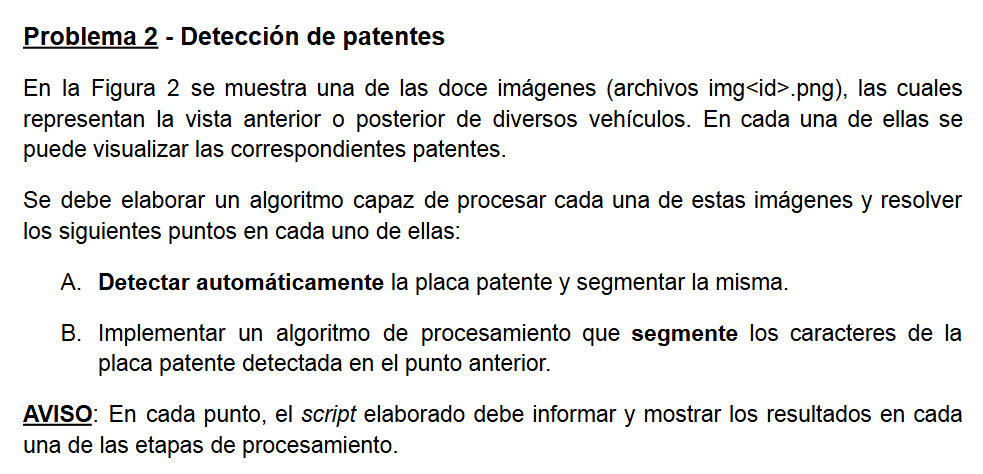

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

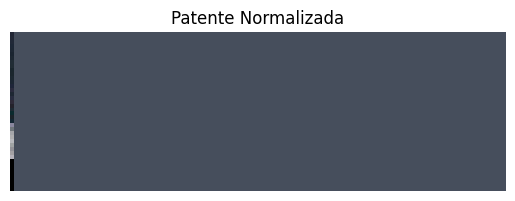

array([[[54, 39, 35],
        [92, 78, 70],
        [92, 78, 70],
        ...,
        [92, 78, 70],
        [92, 78, 70],
        [92, 78, 70]],

       [[55, 41, 36],
        [92, 78, 70],
        [92, 78, 70],
        ...,
        [92, 78, 70],
        [92, 78, 70],
        [92, 78, 70]],

       [[55, 40, 32],
        [92, 78, 70],
        [92, 78, 70],
        ...,
        [92, 78, 70],
        [92, 78, 70],
        [92, 78, 70]],

       ...,

       [[ 0,  0,  0],
        [92, 78, 70],
        [92, 78, 70],
        ...,
        [92, 78, 70],
        [92, 78, 70],
        [92, 78, 70]],

       [[ 0,  0,  0],
        [92, 78, 70],
        [92, 78, 70],
        ...,
        [92, 78, 70],
        [92, 78, 70],
        [92, 78, 70]],

       [[ 0,  0,  0],
        [92, 78, 70],
        [92, 78, 70],
        ...,
        [92, 78, 70],
        [92, 78, 70],
        [92, 78, 70]]], shape=(40, 125, 3), dtype=uint8)

In [11]:
def detectar_patente(ruta_imagen, min_area, max_area):

    img = cv2.imread(ruta_imagen)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filtered = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(filtered, 25, 150) 

    kernel = np.ones((3, 3), np.uint8)
    clausura = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)

    contours, hierarchy = cv2.findContours(clausura.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    patente_contorno = None
    
    for c in contours:

        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.055* perimeter, True) 
        
        if area <min_area or area > max_area: 
            if len(approx) == 4:
                x, y, w, h = cv2.boundingRect(approx)
                aspect_ratio = w / float(h)
                
                if 1.5 <= aspect_ratio <= 3.5:
                    patente_contorno = approx
                    break 
    
    if patente_contorno is not None:
        
        def order_points(pts):
            rect = np.zeros((4, 2), dtype="float32")
            
            s = pts.sum(axis=1)
            rect[0] = pts[np.argmin(s)] 
            rect[2] = pts[np.argmax(s)] 

            diff = np.diff(pts, axis=1)
            rect[1] = pts[np.argmin(diff)] 
            rect[3] = pts[np.argmax(diff)] 

            return rect

        pts = patente_contorno.reshape(4, 2)
        rect = order_points(pts)
        (tl, tr, br, bl) = rect

        max_ancho = max(int(np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))), 
                                    int(np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))))
        
        max_alto = max(int(np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))), 
            int(np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))))

        dst = np.array([[0, 0],[max_ancho - 1, 0],[max_ancho - 1, max_alto - 1],[0, max_alto - 1]], dtype="float32")
        M = cv2.getPerspectiveTransform(rect, dst)
        patente_normalizada = cv2.warpPerspective(img, M, (max_ancho, max_alto))

        plt.imshow(cv2.cvtColor(patente_normalizada, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title('Patente Normalizada')
        plt.show() 
        

        return patente_normalizada

detectar_patente('img/img06.png', 2550,15000)



num_labels_crop, labels_crop, stats_crop, centroids_crop = cv2.connectedComponentsWithStats(crop_caracter, 8, cv2.CV_32S)
            objetos_stats_crop = stats_crop[1:] 
            componentes_validas_crop = []

            for s_crop in objetos_stats_crop:
                x_crop, y_crop, w_crop, h_crop, area_crop = s_crop[0], s_crop[1], s_crop[2], s_crop[3], s_crop[4]
                aspect_ratio_crop = w_crop / h_crop if h_crop != 0 else 0

                if (area_crop >= MIN_AREA_CHARACTER and area_crop <= MAX_AREA_CHARACTER and
                            h_crop >= MIN_HEIGHT_CHARACTER and w_crop <= MAX_WIDTH_CHARACTER and 1.5 < aspect_ratio <3.0 ):
                            componentes_validas.append({'x': x_crop, 'x_fin': x_crop + w_crop})
                            crop_caracter_final = crop_caracter[y_crop:y_crop + h_crop, x_crop:x_crop + w_crop]

                            #break
                            componentes_ordenadas = sorted(componentes_validas_crop, key=lambda c: c['x'])
                            cantidad_caracteres = len(componentes_ordenadas)
                            
                            if cantidad_caracteres <= 1:
                                return (cantidad_caracteres, cantidad_caracteres)

                            espacios_en_blanco = 0
                            palabras_formadas = 1


                            for i in range(cantidad_caracteres - 1):
                                comp_actual = componentes_ordenadas[i]
                                comp_siguiente = componentes_ordenadas[i+1]

                                distancia = comp_siguiente['x'] - comp_actual['x_fin']

                                if distancia >= UMBRAL_ESPACIO_FIJO:
                                    espacios_en_blanco += 1
                                    palabras_formadas += 1
                            

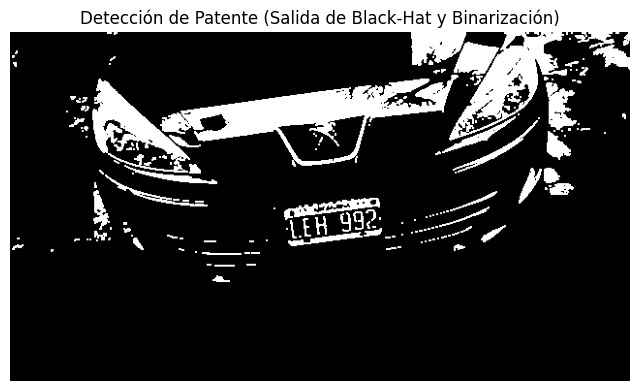

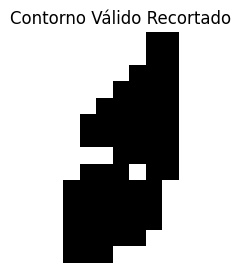

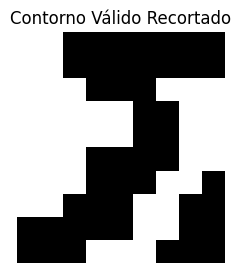

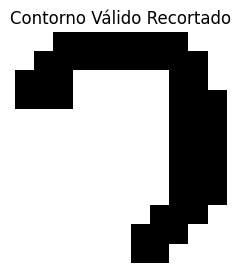

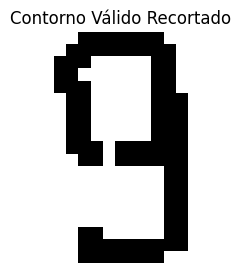

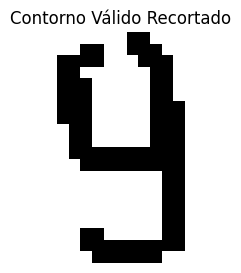

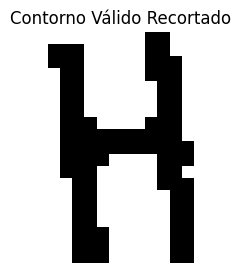

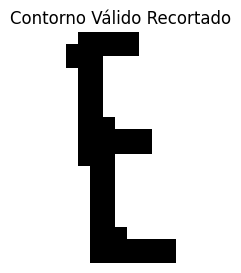

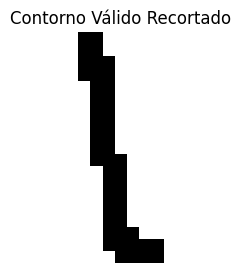

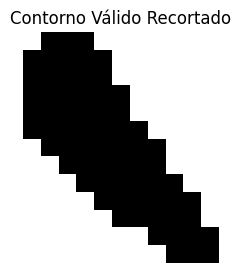

Componentes válidas detectadas (Bounding Boxes): [{'x': np.int32(633), 'y': np.int32(0), 'w': np.int32(7), 'h': np.int32(14), 'area': np.int32(63)}, {'x': np.int32(479), 'y': np.int32(45), 'w': np.int32(9), 'h': np.int32(10), 'area': np.int32(39)}, {'x': np.int32(367), 'y': np.int32(183), 'w': np.int32(11), 'h': np.int32(12), 'area': np.int32(50)}, {'x': np.int32(354), 'y': np.int32(185), 'w': np.int32(11), 'h': np.int32(19), 'area': np.int32(97)}, {'x': np.int32(341), 'y': np.int32(186), 'w': np.int32(11), 'h': np.int32(20), 'area': np.int32(98)}, {'x': np.int32(315), 'y': np.int32(190), 'w': np.int32(12), 'h': np.int32(19), 'area': np.int32(101)}, {'x': np.int32(302), 'y': np.int32(192), 'w': np.int32(9), 'h': np.int32(19), 'area': np.int32(67)}, {'x': np.int32(289), 'y': np.int32(194), 'w': np.int32(7), 'h': np.int32(19), 'area': np.int32(47)}, {'x': np.int32(127), 'y': np.int32(212), 'w': np.int32(11), 'h': np.int32(13), 'area': np.int32(69)}]


In [630]:
def detectar_patente_final_corregido(ruta_imagen,kerneltop, thresh, MIN_AREA_CHARACTER, MAX_AREA_CHARACTER, MIN_HEIGHT_CHARACTER, MAX_WIDTH_CHARACTER): 
    img1 = cv2.imread(ruta_imagen)

    gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    
    kernel_morph = cv2.getStructuringElement(cv2.MORPH_RECT, (kerneltop, kerneltop))

    patente_resaltada = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel_morph) 
    
    _, patente_binaria = cv2.threshold(patente_resaltada, thresh, 255, cv2.THRESH_BINARY) 

    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    patente_dilatada = cv2.dilate(patente_binaria, kernel_dilate, iterations=1)


    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    patente_solida = cv2.morphologyEx(patente_binaria, cv2.MORPH_OPEN, kernel_open)

    invertida = cv2.bitwise_not(patente_solida)
    invertida_abierta = cv2.morphologyEx(invertida, cv2.MORPH_OPEN, kernel_open)
     
    
    plt.figure(figsize=(8, 5))
    plt.imshow(patente_solida, cmap='gray')
    plt.axis('off')
    plt.title("Detección de Patente (Salida de Black-Hat y Binarización)")
    plt.show()

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats((patente_solida), 8, cv2.CV_32S)

    objetos_stats = stats[1:]
           
    if len(objetos_stats) == 0:
        return (f"Cantidad total de caracteres: 0",
                f"Cantidad de espacios 'en blanco' (separaciones entre palabras): 0",
                f"Cantidad de palabras formadas: 0")

    componentes_validas = []
    
    for s in objetos_stats:
        x, y, w, h, area = s[0], s[1], s[2], s[3], s[4]
        aspect_ratio = w / h if h != 0 else 0

        if (area >= MIN_AREA_CHARACTER and area <= MAX_AREA_CHARACTER and
            h >= MIN_HEIGHT_CHARACTER and 0.3 < aspect_ratio < 1.0):
            
            crop_caracter = invertida[y:y + h, x:x + w]
            
            plt.figure(figsize=(3, 3))
            plt.imshow(crop_caracter, cmap='gray')
            plt.axis('off')
            plt.title('Contorno Válido Recortado')
            plt.show()
            componentes_validas.append({'x': x, 'y': y, 'w': w, 'h': h, 'area': area})
    return componentes_validas

resultado = detectar_patente_final_corregido('img/img06.png',81,108, 5, 115, 10, 110)
print(f"Componentes válidas detectadas (Bounding Boxes): {resultado}")

In [ ]:
resultado = detectar_patente_final_corregido('img/img01.png',43, 118, 10, 87, 10, 130)
print(f"Componentes válidas detectadas (Bounding Boxes): {resultado}") # va

resultado = detectar_patente_final_corregido('img/img02.png',48, 86, 7, 76, 10, 110)
print(f"Componentes válidas detectadas (Bounding Boxes): {resultado}") # mejorar

resultado = detectar_patente_final_corregido('img/img05.png',7,122, 5, 75, 10, 110)
print(f"Componentes válidas detectadas (Bounding Boxes): {resultado}") # va

resultado = detectar_patente_final_corregido('img/img06.png',81,108, 5, 115, 10, 110)
print(f"Componentes válidas detectadas (Bounding Boxes): {resultado}") # mejorar


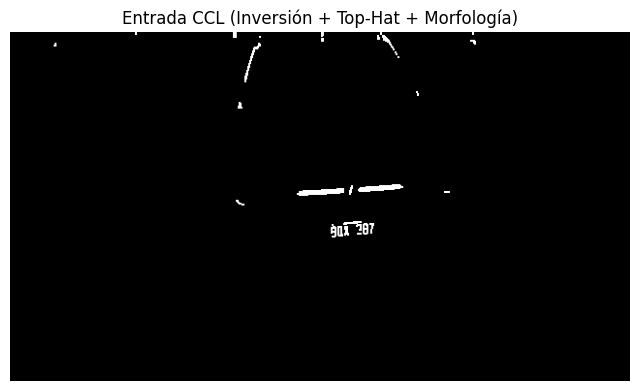

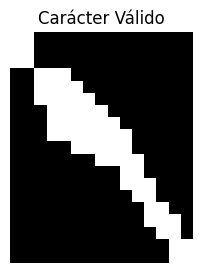

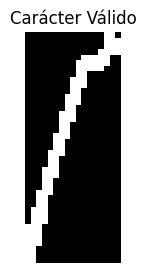

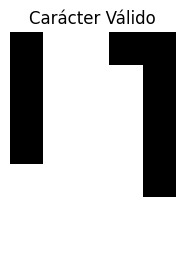

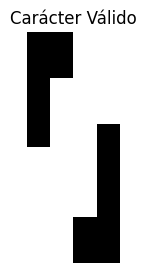

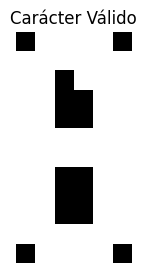

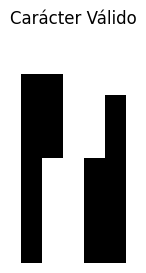

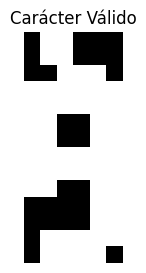

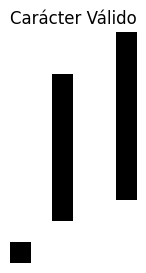

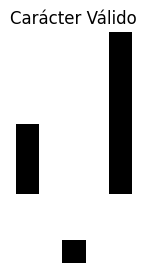

Componentes válidas detectadas (Bounding Boxes): [{'x': np.int32(382), 'y': np.int32(0), 'w': np.int32(15), 'h': np.int32(19), 'area': np.int32(63)}, {'x': np.int32(242), 'y': np.int32(11), 'w': np.int32(17), 'h': np.int32(41), 'area': np.int32(114)}, {'x': np.int32(235), 'y': np.int32(72), 'w': np.int32(5), 'h': np.int32(7), 'area': np.int32(25)}, {'x': np.int32(350), 'y': np.int32(158), 'w': np.int32(4), 'h': np.int32(10), 'area': np.int32(25)}, {'x': np.int32(364), 'y': np.int32(197), 'w': np.int32(6), 'h': np.int32(12), 'area': np.int32(57)}, {'x': np.int32(371), 'y': np.int32(197), 'w': np.int32(5), 'h': np.int32(11), 'area': np.int32(29)}, {'x': np.int32(331), 'y': np.int32(198), 'w': np.int32(6), 'h': np.int32(14), 'area': np.int32(56)}, {'x': np.int32(338), 'y': np.int32(200), 'w': np.int32(6), 'h': np.int32(11), 'area': np.int32(50)}, {'x': np.int32(345), 'y': np.int32(200), 'w': np.int32(5), 'h': np.int32(10), 'area': np.int32(39)}]


In [321]:
def detectar_patente_FINAL_INVERSION_TOPHAT(ruta_imagen, thresh, MIN_AREA_CHARACTER, MAX_AREA_CHARACTER, MIN_HEIGHT_CHARACTER, MAX_WIDTH_CHARACTER):
    
    img1 = cv2.imread(ruta_imagen)

    gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

    #gray_invertida = cv2.bitwise_not(gray) 
 
    kernel_morph = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    placa_resaltada = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel_morph) 

    _, patente_binaria = cv2.threshold(placa_resaltada, thresh, 255, cv2.THRESH_BINARY) 

    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    patente_dilatada = cv2.dilate(patente_binaria, kernel_dilate, iterations=1)

    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    patente_solida = cv2.morphologyEx(patente_dilatada, cv2.MORPH_OPEN, kernel_open)

    plt.figure(figsize=(8, 5))
    plt.imshow(patente_solida, cmap='gray')
    plt.axis('off')
    plt.title("Entrada CCL (Inversión + Top-Hat + Morfología)")
    plt.show()

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(patente_solida, 8, cv2.CV_32S)
    objetos_stats = stats[1:]
    componentes_validas = []
    
    if len(objetos_stats) == 0:
        return ("Cantidad total de caracteres: 0", "Cantidad de separaciones 'en blanco': 0", "Cantidad de palabras formadas: 0")

    for s in objetos_stats:
        x, y, w, h, area = s[0], s[1], s[2], s[3], s[4]
        aspect_ratio = w / h if h != 0 else 0

        if (area >= MIN_AREA_CHARACTER and area <= MAX_AREA_CHARACTER and
            h >= MIN_HEIGHT_CHARACTER and 0.3 < aspect_ratio < 1.0):
            
            crop_caracter = patente_solida[y:y + h, x:x + w]

            plt.figure(figsize=(3, 3))
            plt.imshow(crop_caracter, cmap='gray')
            plt.axis('off')
            plt.title('Carácter Válido')
            plt.show()
            
            componentes_validas.append({'x': x, 'y': y, 'w': w, 'h': h, 'area': area})

    return componentes_validas

resultado = detectar_patente_FINAL_INVERSION_TOPHAT('img/img12.png', 105, 10, 1650, 7, 250)
print(f"Componentes válidas detectadas (Bounding Boxes): {resultado}")